<a href="https://colab.research.google.com/github/nicolle-tq/Telecom-X-parte-2-/blob/main/Telecom-X-parte-2-.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Introducción**

En este proyecto se desarrolla un modelo de machine learning para predecir la cancelación de clientes (churn) en la empresa Telecom X.
Se utilizan datos tratados en el challenge anterior para entrenar modelos de clasificación que permitan identificar clientes con mayor riesgo de cancelación.


# **Importar librerías**

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# **Cargar archivo tratado**

In [49]:
df = pd.read_csv("datos_tratados.csv")

df.head()

,Cliente_ID,Churn,Genero,Adulto_Mayor,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,Tipo_Contrato,account.PaperlessBilling,account.PaymentMethod,Cargo_Mensual,Cargo_Total,Cuentas_Diarias,Churn_binario
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667,0.0
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667,0.0
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,1.0
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,1.0
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667,1.0


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7256 entries, 0 to 7255
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Cliente_ID                 7256 non-null   object 
 1   Churn                      7032 non-null   object 
 2   Genero                     7256 non-null   object 
 3   Adulto_Mayor               7256 non-null   object 
 4   customer.Partner           7256 non-null   object 
 5   customer.Dependents        7256 non-null   object 
 6   customer.tenure            7256 non-null   int64  
 7   phone.PhoneService         7256 non-null   object 
 8   phone.MultipleLines        7256 non-null   object 
 9   internet.InternetService   7256 non-null   object 
 10  internet.OnlineSecurity    7256 non-null   object 
 11  internet.OnlineBackup      7256 non-null   object 
 12  internet.DeviceProtection  7256 non-null   object 
 13  internet.TechSupport       7256 non-null   objec

# **Preparación de los datos**

In [51]:
# eliminar columnas si existen
df = df.drop(columns=["Cliente_ID", "Churn"], errors="ignore")

# convertir variables categóricas
df = pd.get_dummies(df, drop_first=True)

# separar variables
X = df.drop("Churn_binario", axis=1)
y = df["Churn_binario"]

# **Revisar proporción de cancelación**

In [52]:
y.value_counts()

,count
Churn_binario,
0.0,5163
1.0,1869


In [53]:
y.value_counts(normalize=True)

,proportion
Churn_binario,
0.0,0.734215
1.0,0.265785


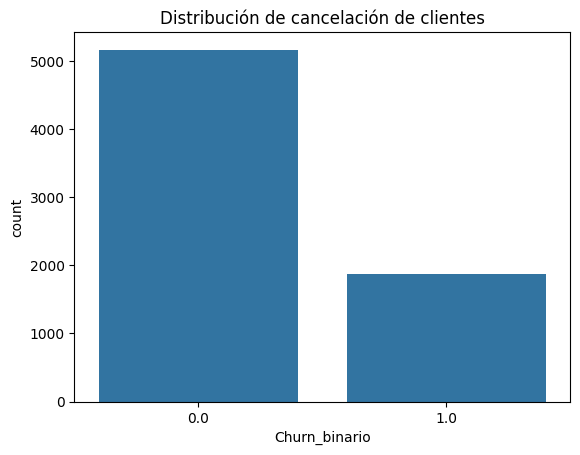

In [54]:
# Gráfico:
sns.countplot(x=y)
plt.title("Distribución de cancelación de clientes")
plt.show()

# **Análisis de correlación**

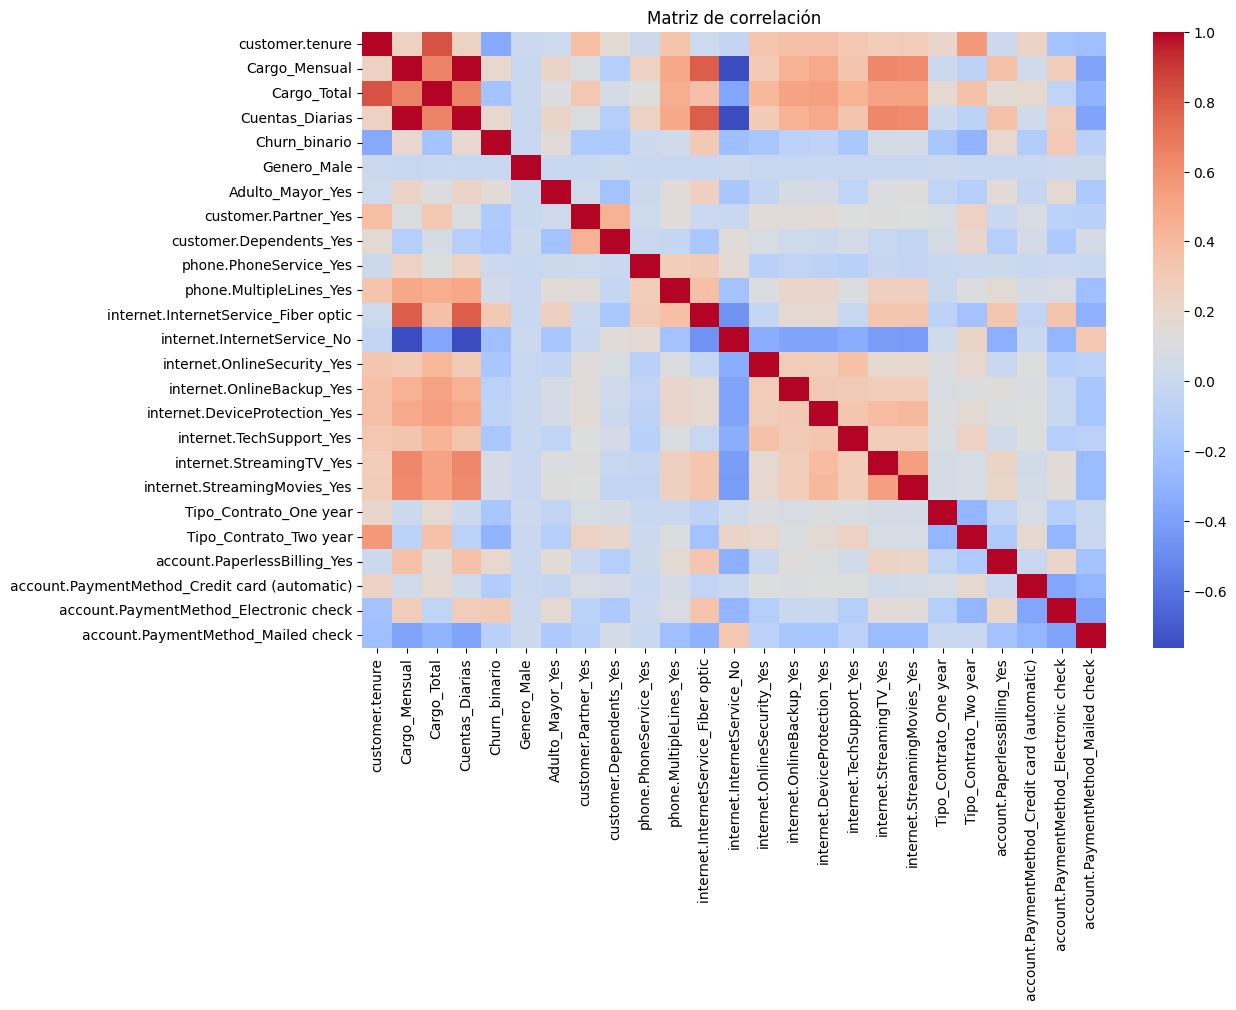

In [55]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

In [56]:
df.corr()["Churn_binario"].sort_values(ascending=False)

,Churn_binario
Churn_binario,1.000000
internet.InternetService_Fiber optic,0.307463
account.PaymentMethod_Electronic check,0.301455
Cuentas_Diarias,0.192858
Cargo_Mensual,0.192858
account.PaperlessBilling_Yes,0.191454
Adulto_Mayor_Yes,0.150541
internet.StreamingTV_Yes,0.063254
internet.StreamingMovies_Yes,0.060860
phone.MultipleLines_Yes,0.040033


# **Separar entrenamiento y prueba**

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# **Normalización (para regresión logística)**

In [58]:
# eliminar filas con valores nulos
df = df.dropna()

In [59]:
X = df.drop("Churn_binario", axis=1)
y = df["Churn_binario"]

In [60]:
# separar entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Entrenar modelos**

**Modelo 1 — Regresión Logística**

In [62]:
y.isna().sum()

np.int64(0)

In [63]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(max_iter=1000)

modelo_lr.fit(X_train_scaled, y_train)

pred_lr = modelo_lr.predict(X_test_scaled)

**Evaluar y comparar modelos**

In [64]:
print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

         0.0       0.85      0.89      0.87      1554
         1.0       0.64      0.57      0.60       556

    accuracy                           0.80      2110
   macro avg       0.75      0.73      0.74      2110
weighted avg       0.80      0.80      0.80      2110



**Matriz**

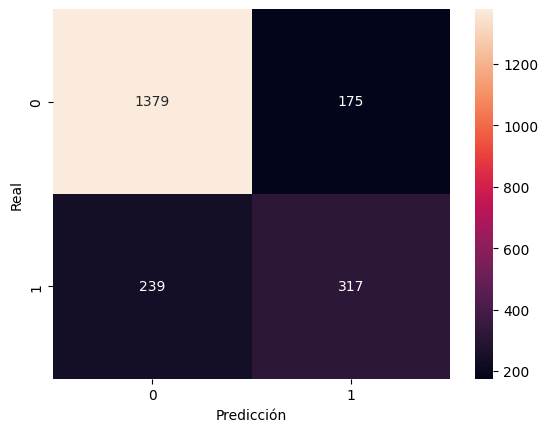

In [65]:
cm = confusion_matrix(y_test, pred_lr)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

**Modelo 2 — Árbol de Decisión**

In [66]:
model_tree = DecisionTreeClassifier()

model_tree.fit(X_train, y_train)

pred_tree = model_tree.predict(X_test)

**Evaluación**

In [67]:
print(classification_report(y_test, pred_tree))

              precision    recall  f1-score   support

         0.0       0.82      0.79      0.80      1554
         1.0       0.47      0.52      0.49       556

    accuracy                           0.72      2110
   macro avg       0.64      0.65      0.65      2110
weighted avg       0.73      0.72      0.72      2110



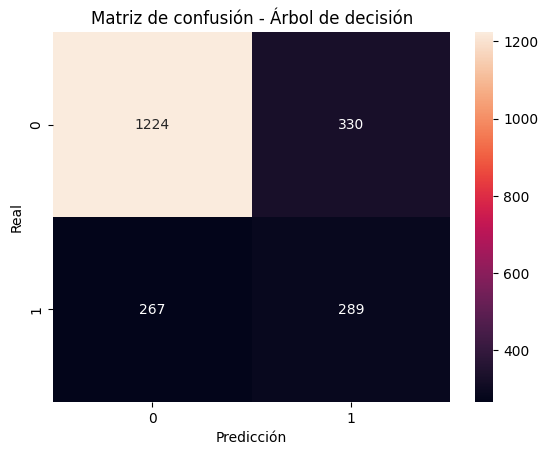

In [68]:
# Matriz de confusión - Árbol de decisión
cm_tree = confusion_matrix(y_test, pred_tree)

sns.heatmap(cm_tree, annot=True, fmt="d")
plt.title("Matriz de confusión - Árbol de decisión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

## **Comparación de modelos**

Se compararon dos modelos de clasificación: Regresión Logística y Árbol de Decisión.
Se analizaron métricas como precisión, recall y F1-score para evaluar cuál modelo predice mejor la cancelación de clientes.

Se entrenaron dos modelos de clasificación: Regresión Logística y Árbol de Decisión.
Al comparar las métricas obtenidas, se puede observar que uno de los modelos presenta mejor equilibrio entre precisión y recall.
Esto permite identificar de manera más efectiva a los clientes con mayor riesgo de cancelar el servicio.

## **Importancia de variables**

In [69]:
importances = model_tree.feature_importances_

importance_df = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": importances
}).sort_values(by="Importancia", ascending=False)

importance_df.head(10)

,Variable,Importancia
0,customer.tenure,0.208352
2,Cargo_Total,0.203508
1,Cargo_Mensual,0.107396
10,internet.InternetService_Fiber optic,0.106247
3,Cuentas_Diarias,0.086838
4,Genero_Male,0.028641
13,internet.OnlineBackup_Yes,0.023261
19,Tipo_Contrato_Two year,0.021746
6,customer.Partner_Yes,0.020953
14,internet.DeviceProtection_Yes,0.019363


# **Conclusión**

El análisis permitió identificar variables relevantes en la cancelación de clientes.
Los modelos de machine learning utilizados (Regresión Logística y Árbol de Decisión) permiten estimar la probabilidad de churn a partir de características del cliente.
Factores como el gasto mensual, el tipo de contrato y la duración del servicio parecen influir en la cancelación.
Esta información puede ayudar a Telecom X a identificar clientes con mayor riesgo y diseñar estrategias de retención.